In [13]:
from pathlib import Path
import numpy as np
from MNIST.Encode_0to9 import encode_diagonal
threshold = 0.4

ROOT = Path.cwd()

test_path = ROOT / "data" / f"test_MNIST_10x10_binarize{threshold}.npy"
label_path = ROOT / "data" / "test_MNIST_labels.npy"

X_test = np.load(test_path)
X_test = X_test.reshape(X_test.shape[0], -1)
X_test = X_test.astype(int)
X_flip = 1 - X_test# 01反转，由于不反转时0的比例太多了，1的比例太少了。
x_test_bitstrings=np.array(["".join(map(str, row)) for row in X_flip], dtype=str)
Y_test = np.load(label_path)
y_test_encoded= np.array([encode_diagonal(label) for label in Y_test])#不压平，保持10x10的形状，方便后续处理。

print(f"Loaded: {test_path}")
print(f"X_test shape: {X_test.shape}, dtype: {X_test.dtype}")

theta_path = ROOT / "data" / f"estimate_theta_binarized{threshold}.npz"
if not theta_path.exists():
	raise FileNotFoundError(f"未找到参数文件: {theta_path}")
with np.load(theta_path) as data:
	theta_hat_matrix = data["theta_hat_matrix"]
theta_hat_matrix_flat = theta_hat_matrix.reshape(-1)
#print(theta_hat_matrix)
print(f"first 100 labels: {Y_test[:100]}")

Loaded: d:\研究生\研究生\Quantum Machine learning\code\MNIST\data\test_MNIST_10x10_binarize0.4.npy
X_test shape: (10000, 100), dtype: int32
first 100 labels: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1 3 1 3 4 7 2 7
 1 2 1 1 7 4 2 3 5 1 2 4 4 6 3 5 5 6 0 4 1 9 5 7 8 9 3 7 4 6 4 3 0 7 0 2 9
 1 7 3 2 9 7 7 6 2 7 8 4 7 3 6 1 3 6 9 3 1 4 1 7 6 9]


test_bitstring: 1111111111111111111111100011111110000111110111011111000001111111010111111111011111111101111111111111


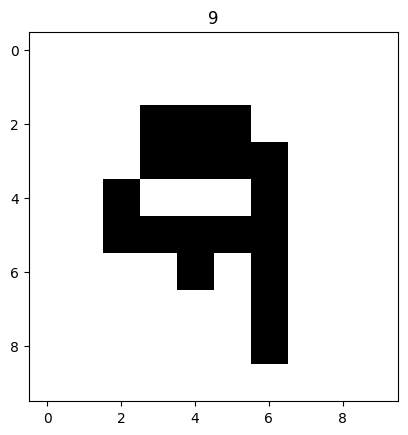

In [9]:
import random
n1=10
m=10
seed = 42
random.seed(seed)
n_number=10000#对于一个seed生成的n_number个y值
test_number=99
test_bitstring=x_test_bitstrings[test_number]
print(f"test_bitstring: {test_bitstring}")

import matplotlib.pyplot as plt

plt.imshow(X_flip.reshape(-1, 10, 10)[test_number], cmap='gray')
plt.title(Y_test[test_number])
plt.show()


In [10]:
from sampling.DQNN_generate_y import DQNN_generate_y
from tqdm import tqdm

y_generated =[]

for i in tqdm(range(n_number)):
    _,y= DQNN_generate_y(test_bitstring, n1, m, theta_hat_matrix_flat)
    y_generated.append(y)

y_generated=np.array(y_generated)

100%|██████████| 10000/10000 [47:21<00:00,  3.52it/s]


(10000, 100)
(100,)


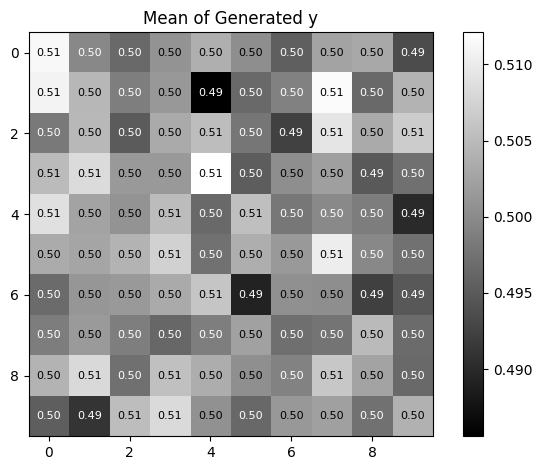

In [17]:
y_mean = y_generated.mean(axis=0)
y_mean_img=y_mean.reshape(10,10)
# np.save(ROOT / "data" /"distance_related"/ f"y_generated_mean_{test_number}th_number{n_number}times_binarized{threshold}.npy", y_mean)

print(y_generated.shape)
print(y_mean.shape)
plt.imshow(y_mean_img, cmap='gray')
plt.title("Mean of Generated y")
plt.colorbar()   
# plt.show()

for i in range(y_mean_img.shape[0]):
    for j in range(y_mean_img.shape[1]):
        val = y_mean_img[i, j]
        
        # 根据背景自动选择文字颜色（关键细节）
        color = "white" if val < 0.5 else "black"
        
        plt.text(
            j, i,
            f"{val:.2f}",   # 保留2位小数
            ha='center',
            va='center',
            color=color,
            fontsize=8
        )

plt.tight_layout()
plt.show()


In [ ]:
output_dir = ROOT / "output_images" / "compare"
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / filename
print(output_dir)

d:\研究生\研究生\Quantum Machine learning\code\MNIST\output_images\compare


FileNotFoundError: [Errno 2] No such file or directory: 'd:\\研究生\\研究生\\Quantum Machine learning\\code\\MNIST\\output_images\\compare\\mean_vs_encoded_n1_10_m_10_seed_42_nNumber_10000_testIdx_99_trueLabel_9_bitstring_1111111111111111111111100011111110000111110111011111000001111111010111111111011111111101111111111111_binarized_0.4.png'

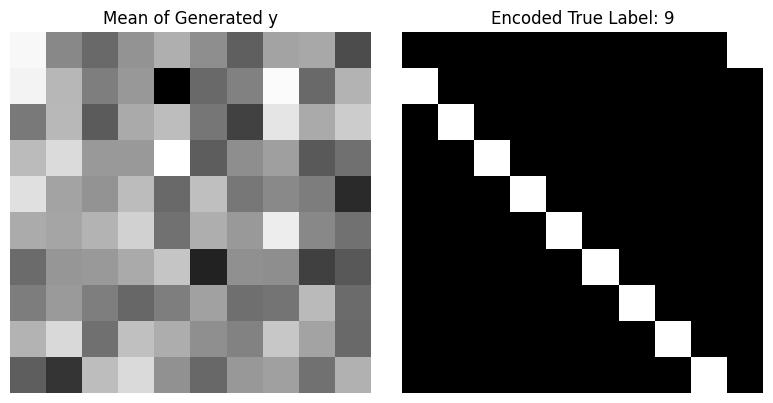

In [14]:
y_mean = y_generated.mean(axis=0)
y_mean_img=y_mean.reshape(10,10)

output_dir = ROOT / "output_images" / "compare"
output_dir.mkdir(parents=True, exist_ok=True)

bitstring_text = str(test_bitstring)
filename = (
    f"mean_vs_encoded_"
    f"n1_{n1}_m_{m}_seed_{seed}_nNumber_{n_number}_"
    f"testIdx_{test_number}_trueLabel_{int(Y_test[test_number])}_"
    f"bitstring_{bitstring_text}_"
    f"binarized_{threshold}.png"
)
save_path = output_dir / filename

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(y_mean_img, cmap='gray')
axes[0].set_title("Mean of Generated y")
axes[0].axis("off")

axes[1].imshow(y_test_encoded[test_number], cmap='gray')
axes[1].set_title(f"Encoded True Label: {Y_test[test_number]}")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")

测试学习到的参数在train dataset上能不能使用（结果极差）

In [108]:
train_path = ROOT / "data" / f"MNIST_10x10_binarize{threshold}.npy"
train_label_path = ROOT / "data" / "MNIST_labels.npy"
X_train = np.load(train_path)
X_train = X_train.reshape(X_train.shape[0], -1)
X_train = X_train.astype(int)
X_train_flip = 1 - X_train# 01反转，由于不反转时0的比例太多了，1的比例太少了。
x_train_bitstrings=np.array(["".join(map(str, row)) for row in X_train_flip], dtype=str)
Y_train = np.load(train_label_path)
y_train_encoded= np.array([encode_diagonal(label) for label in Y_train])#不压平，保持10x10的形状，方便后续处理。


In [104]:
from sampling.DQNN_generate_y import DQNN_generate_y
from tqdm import tqdm

y_generated_trian =[]

for i in tqdm(range(n_number)):
    _,y= DQNN_generate_y(x_train_bitstrings[0], n1, m, theta_hat_matrix_flat)
    y_generated_trian.append(y)

y_generated_trian=np.array(y_generated_trian)

100%|██████████| 1000/1000 [02:16<00:00,  7.33it/s]


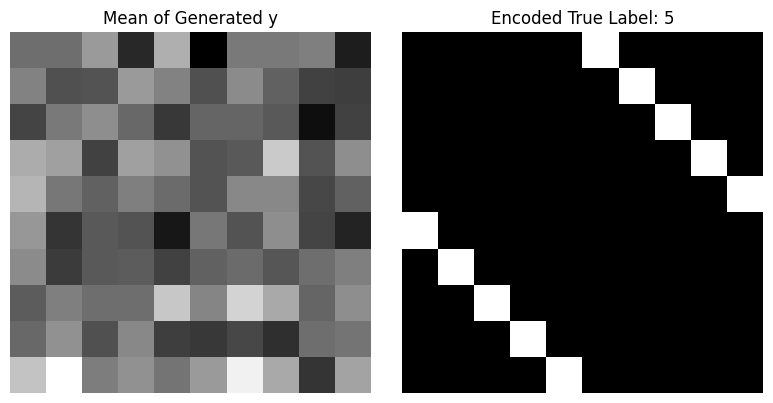

In [107]:
y_train_mean = y_generated_trian.mean(axis=0)
y_train_mean_img=y_train_mean.reshape(10,10)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(y_mean_img, cmap='gray')
axes[0].set_title("Mean of Generated y")
axes[0].axis("off")

axes[1].imshow(y_train_encoded[0], cmap='gray')
axes[1].set_title(f"Encoded True Label: {Y_train[0]}")
axes[1].axis("off")

plt.tight_layout()
plt.show()